**MAESTRÍA EN ECONOMÍA APLICADA - UBA 2025**
**TALLER DE PROGRAMACIÓN**
**GRUPO 2**

In [14]:
# Carga de usuario para simplificar paths de acceso según quién ejecute el código
print("Ingrese su número de referencia de usuario de la lista\nAlvarez - 1\nGodino - 2\nSulca - 3\nOtro usuario - 4:")
usuario = input("Ingrese su número de referencia de usuario de la lista\nAlvarez - 1\nGodino - 2\nSulca - 3\nOtro usuario - 4:")
if usuario == '1':
    nombre = "Alvarez"
    path = "C:\\Users\\marti\\OneDrive\\Documentos\\"
elif usuario == '2':
    nombre = "Alvarez"
    path = "C:\\Users\\Usuario\\Documents\\"
elif usuario == '3':
    nombre = "Alvarez"
    path = "C:\\Users\\user\\Documents\\"
elif usuario == '4':
    print("A modo de ejemplo, el path a la carpeta Github debe tener esta forma: C:\\Users\\Usuario\\Documents\\")
    path = input("Ingrese el path en su computadora a la carpeta Github: ")
print(f"Path cargado correctamente")

Ingrese su número de referencia de usuario de la lista
Alvarez - 1
Godino - 2
Sulca - 3
Otro usuario - 4:
Path cargado correctamente


In [46]:
# Librerías a utilizar
# !pip install openpyxl - utilizar en caso no te cargue el archivo de excel
import pandas as pd
import numpy as np
import seaborn as sns   
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

# TP3

In [43]:
# Importamos la base construida en el TP1
respondieron = pd.read_csv(path+"GitHub\\Big-Data-UBA--Grupo-2\\base de datos\\respondieron.csv")
norespondieron = pd.read_csv(path+"GitHub\\Big-Data-UBA--Grupo-2\\base de datos\\norespondieron.csv")

## PARTE A: Separación train/test por año

In [44]:
# ======================
# Separar respondieron
# ======================
respondieron_2005 = respondieron[respondieron['df'] == 'T105'].copy()
respondieron_2025 = respondieron[respondieron['df'] == 'T125'].copy()

# ======================
# Separar norespondieron
# ======================
norespondieron_2005 = norespondieron[norespondieron['df'] == 'T105'].copy()
norespondieron_2025 = norespondieron[norespondieron['df'] == 'T125'].copy()


In [64]:
# ======================
# SELECCIÓN DE VARIABLES (sin ingresos)
# ======================
              # Sexo, Edad, Estado Civil, Nivel Educativo, Estado Ocup, Inactividad, Ocupación, Meses buscando empleo, Buscó más horas
variables_X = ['ch04', 'ch06', 'ch07', 'nivel_ed', 'estado', 'cat_inac', 'cat_ocup', 'pp10a', 'pp03i' ]

#### 2005
#########

X = respondieron_2005[variables_X].copy()
y = respondieron_2005['pobre'].astype(int)
# Agregar intercepto (columna de unos)
X['intercept'] = 1

# TRAIN/TEST SPLIT
X_train_2005, X_test_2005, y_train_2005, y_test_2005 = train_test_split(
    X, y, test_size=0.30, random_state=444)

# TABLA DE MEDIAS ENTRE TRAIN Y TEST
tabla_medias = pd.DataFrame({
    'Media_Train': X_train_2005.mean(),
    'Media_Test': X_test_2005.mean(),
    'Diferencia': X_train_2005.mean() - X_test_2005.mean()
    })

tabla_medias.to_excel(path+"GitHub\\Big-Data-UBA--Grupo-2\\TP3\\tabla_medias_2005.xlsx")

#### 2025
#########

X = respondieron_2025[variables_X].copy()
y = respondieron_2025['pobre'].astype(int)
# Agregar intercepto (columna de unos)
X['intercept'] = 1

# TRAIN/TEST SPLIT
X_train_2025, X_test_2025, y_train_2025, y_test_2025 = train_test_split(
    X, y, test_size=0.30, random_state=444)

# TABLA DE MEDIAS ENTRE TRAIN Y TEST
tabla_medias = pd.DataFrame({
    'Media_Train': X_train_2025.mean(),
    'Media_Test': X_test_2025.mean(),
    'Diferencia': X_train_2025.mean() - X_test_2025.mean()
    })

tabla_medias.to_excel(path+"GitHub\\Big-Data-UBA--Grupo-2\\TP3\\tabla_medias_2025.xlsx")

## PARTE B. Modelo de Regresion Logística

In [68]:
# Revisamos NaNs
print(X_train_2025.shape)
print(X_train_2025.isna().sum())
# Rellenamos con ceros los NaNs ya que para esas variables 0 no es un valor utilizado
X_train_2025 = X_train_2025.fillna(0)
X_test_2025 = X_test_2025.fillna(0)

(6086, 10)
ch04            0
ch06            0
ch07            0
nivel_ed        0
estado          0
cat_inac     2863
cat_ocup     3256
pp10a        5951
pp03i        3360
intercept       0
dtype: int64


In [77]:
import statsmodels.api as sm
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split


# Modelo para 2025
logit_model = sm.Logit(y_train_2025, X_train_2025)
resultado = logit_model.fit()
print(resultado.summary2())

# Guardamos los coeficientes
coeficientes = resultado.params[:]  # Excluir el intercepto

# Calculamos los odds ratio
odds_ratio = np.exp(coeficientes)

# Guardamos el error estándar
std_error = resultado.bse[:]  # Excluir el intercepto

# Creamos la tabla
tabla_resultados = pd.DataFrame({
    #'Variable': X.columns esta linea para cuando tengan muchas variables
    'Coeficiente': coeficientes,
    'Std. Error': std_error,
    'Odds Ratio': odds_ratio
})

tabla_resultados.round(2)

Optimization terminated successfully.
         Current function value: 0.614587
         Iterations 5
                          Results: Logit
Model:              Logit            Method:           MLE        
Dependent Variable: pobre            Pseudo R-squared: 0.106      
Date:               2025-11-16 15:37 AIC:              7500.7512  
No. Observations:   6086             BIC:              7567.8886  
Df Model:           9                Log-Likelihood:   -3740.4    
Df Residuals:       6076             LL-Null:          -4182.0    
Converged:          1.0000           LLR p-value:      2.5649e-184
No. Iterations:     5.0000           Scale:            1.0000     
-------------------------------------------------------------------
               Coef.   Std.Err.     z      P>|z|    [0.025   0.975]
-------------------------------------------------------------------
ch04           0.1200    0.0568    2.1120  0.0347   0.0086   0.2313
ch06          -0.0317    0.0018  -17.9483  0.0000

,Coeficiente,Std. Error,Odds Ratio
ch04,0.12,0.06,1.13
ch06,-0.03,0.00,0.97
ch07,-0.11,0.02,0.90
nivel_ed,-0.23,0.02,0.80
estado,-0.94,0.08,0.39
cat_inac,0.29,0.03,1.33
cat_ocup,-0.11,0.06,0.90
pp10a,0.37,0.08,1.45
pp03i,-0.60,0.09,0.55
intercept,4.10,0.31,60.14


In [86]:
# Predicción para ver rango
y_pred_score = resultado.predict(X_test_2025)  
print('promedio de predicción Prob(y=1|X): ', y_pred_score.mean().round(3))
print('min de predicción Prob(y=1|X): ', y_pred_score.min().round(3))
print('max de predicción Prob(y=1|X): ', y_pred_score.max().round(3))
# Adentro del rango!

promedio de predicción Prob(y=1|X):  0.446
min de predicción Prob(y=1|X):  0.056
max de predicción Prob(y=1|X):  0.917


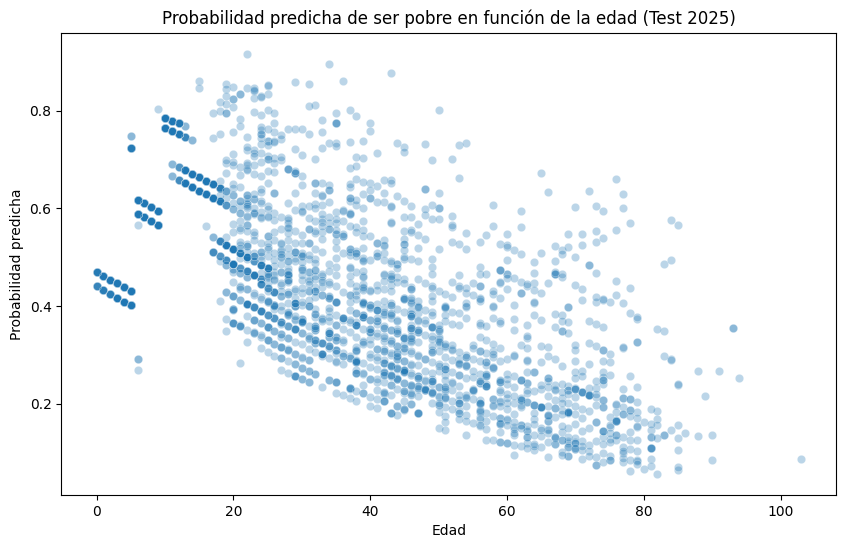

In [83]:
# =========================================
# CONSIGNA 4: Gráfico de la probabilidad predicha en test en función de edad
# =========================================

# Unimos en un df edad y predicción
datos = pd.DataFrame({
    'edad': X_test_2025['ch06'],
    'prediccion': y_pred_score
})

# Graficamos
plt.figure(figsize=(10,6))
sns.scatterplot(data=datos, x='edad', y='prediccion', alpha=0.3)
plt.title('Probabilidad predicha de ser pobre en función de la edad (Test 2025)')
plt.xlabel('Edad')
plt.ylabel('Probabilidad predicha')
plt.show()

## PARTE C. Método de Vecinos Cercanos (KNN)

Consigna 5

In [51]:
variables_knn = variables_X.copy()   # mismas variables que para el logit
variables_knn.append('pobre')

# Hacemos train con SOLO esas variables
train_knn = pd.concat([X_train_2025, y_train_2025], axis=1)

# Eliminamos solo filas donde falten datos relevantes
train_knn = train_knn.dropna(subset=variables_knn)

# Reconstruimos X y y limpios
X_train_knn = train_knn[X_train_2025.columns]
y_train_knn = train_knn['pobre']

print("Filas disponibles para KNN:", X_train_knn.shape[0])


Filas disponibles para KNN: 6086


In [52]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

K_values = [1, 5, 10]
resultados_knn = {}

for k in K_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_knn, y_train_knn)

    y_pred = knn.predict(X_train_knn)
    acc = accuracy_score(y_train_knn, y_pred)

    resultados_knn[k] = acc
    print(f"K={k}: Accuracy (train) = {acc:.4f}")


K=1: Accuracy (train) = 0.9839
K=5: Accuracy (train) = 0.7718
K=10: Accuracy (train) = 0.7291


Consigna 6

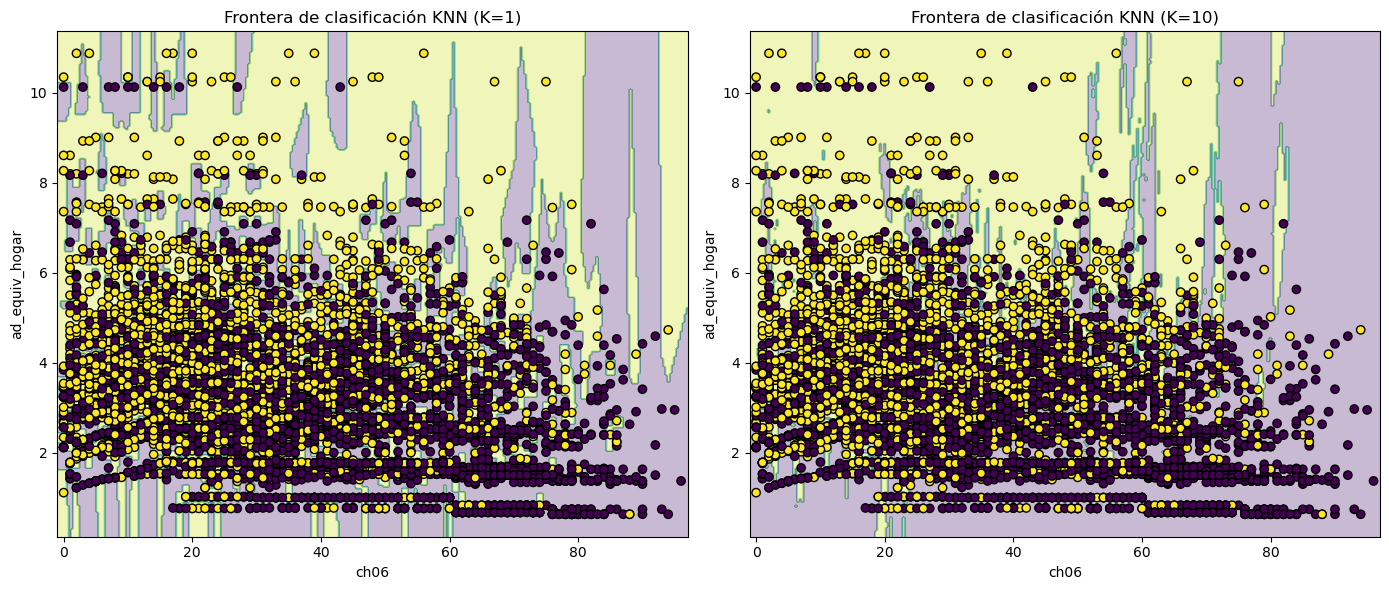

In [53]:
# ==================================
# 6) Visualización de fronteras KNN
# ==================================

import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier

# Seleccionar dos variables numéricas
var1 = "ch06"
var2 = "ad_equiv_hogar"

X_plot = X_train_knn[[var1, var2]].values
y_plot = y_train_knn.values

# Crear una malla para dibujar la frontera
x_min, x_max = X_plot[:, 0].min() - 1, X_plot[:, 0].max() + 1
y_min, y_max = X_plot[:, 1].min() - 0.5, X_plot[:, 1].max() + 0.5

xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300),
                     np.linspace(y_min, y_max, 300))

fig, axes = plt.subplots(1, 2, figsize=(14,6))

for ax, k in zip(axes, [1, 10]):
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_plot, y_plot)

    Z = knn.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    ax.contourf(xx, yy, Z, alpha=0.3, cmap='viridis')
    ax.scatter(X_plot[:, 0], X_plot[:, 1], c=y_plot, cmap='viridis', edgecolors='k')
    ax.set_title(f"Frontera de clasificación KNN (K={k})")
    ax.set_xlabel(var1)
    ax.set_ylabel(var2)

plt.tight_layout()
plt.show()


Consigna 7

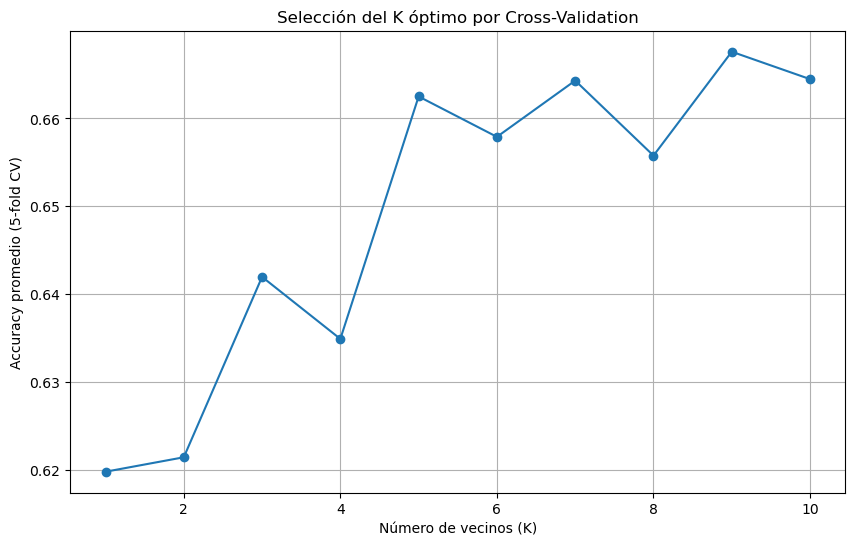

➡️ El K óptimo por 5-fold CV es: 9


In [54]:
# ==========================================
# 7) Selección de K óptimo por 5-fold CV
# ==========================================

from sklearn.model_selection import KFold, cross_val_score
from sklearn.neighbors import KNeighborsClassifier
import matplotlib.pyplot as plt
import numpy as np

K_range = range(1, 11)
cv_scores = []

kf = KFold(n_splits=5, shuffle=True, random_state=444)

for k in K_range:
    knn = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(knn, 
                             X_train_knn, 
                             y_train_knn,
                             cv=kf, 
                             scoring='accuracy')
    cv_scores.append(scores.mean())

# Gráfico del accuracy por K
plt.figure(figsize=(10,6))
plt.plot(K_range, cv_scores, marker='o')
plt.xlabel("Número de vecinos (K)")
plt.ylabel("Accuracy promedio (5-fold CV)")
plt.title("Selección del K óptimo por Cross-Validation")
plt.grid(True)
plt.show()

best_k = K_range[np.argmax(cv_scores)]
print(f"➡️ El K óptimo por 5-fold CV es: {best_k}")


Parte D. Desempeño de modelos afuera de la muestra, métricas y politicas públicas

Consigna 8

1. MATRIZ DE CONFUSIÓN — LOGIT (umbral p > 0.5)

In [55]:
from sklearn.metrics import confusion_matrix

# Predicción con LOGIT en test
y_pred_logit_prob = resultado.predict(X_test_2025)
y_pred_logit = (y_pred_logit_prob > 0.5).astype(int)

cm_logit = confusion_matrix(y_test_2025, y_pred_logit)
cm_logit


array([[1022,  409],
       [ 391,  787]])

2. CURVA ROC — LOGIT vs KNN (K óptimo)

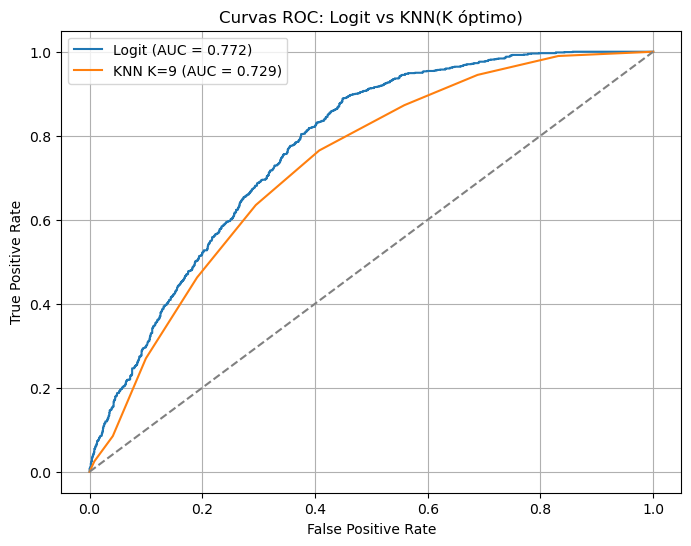

In [56]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Entrenar KNN con K óptimo
knn_cv = KNeighborsClassifier(n_neighbors=best_k)
knn_cv.fit(X_train_knn, y_train_knn)

# Probabilidades para curva ROC (en KNN es proporción de vecinos)
y_pred_knn_prob = knn_cv.predict_proba(X_test_2025)[:,1]

# ROC Logit
fpr_logit, tpr_logit, _ = roc_curve(y_test_2025, y_pred_logit_prob)
roc_auc_logit = auc(fpr_logit, tpr_logit)

# ROC KNN
fpr_knn, tpr_knn, _ = roc_curve(y_test_2025, y_pred_knn_prob)
roc_auc_knn = auc(fpr_knn, tpr_knn)

plt.figure(figsize=(8,6))
plt.plot(fpr_logit, tpr_logit, label=f"Logit (AUC = {roc_auc_logit:.3f})")
plt.plot(fpr_knn, tpr_knn, label=f"KNN K={best_k} (AUC = {roc_auc_knn:.3f})")
plt.plot([0,1], [0,1], '--', color='gray')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Curvas ROC: Logit vs KNN(K óptimo)")
plt.legend()
plt.grid(True)
plt.show()


3. TABLA DE MÉTRICAS (Accuracy – F1 – Recall – Precision)

In [57]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pandas as pd

metricas = pd.DataFrame({
    "Modelo": ["Logit", f"KNN (K={best_k})"],
    "Accuracy": [
        accuracy_score(y_test_2025, y_pred_logit),
        accuracy_score(y_test_2025, knn_cv.predict(X_test_2025))
    ],
    "Precision": [
        precision_score(y_test_2025, y_pred_logit),
        precision_score(y_test_2025, knn_cv.predict(X_test_2025))
    ],
    "Recall": [
        recall_score(y_test_2025, y_pred_logit),
        recall_score(y_test_2025, knn_cv.predict(X_test_2025))
    ],
    "F1-score": [
        f1_score(y_test_2025, y_pred_logit),
        f1_score(y_test_2025, knn_cv.predict(X_test_2025))
    ]
})

metricas


,Modelo,Accuracy,Precision,Recall,F1-score
0,Logit,0.693369,0.658027,0.668081,0.663016
1,KNN (K=9),0.673438,0.639316,0.634975,0.637138
